# Chapter 4: Regression and Prediction

## 1. Summary / Ringkasan Bab
Bab ini membahas penggunaan model regresi untuk memprediksi nilai kontinu berdasarkan satu atau lebih variabel prediktor. Fokus utamanya mencakup Regresi Linear Sederhana (Simple Linear Regression), Regresi Linear Berganda (Multiple Linear Regression), Evaluasi Kinerja Model (RMSE, R-squared, Adjusted R-squared), Diagnostik Model (Outliers, Influential Values, Heteroskedasticity), serta Regresi Polinomial dan Spline.

## 2. Theoretical Deep-Dive
- **Simple & Multiple Linear Regression**:
  - *Simple Linear Regression*: Memodelkan hubungan linier antara satu variabel independen ($X$) dan satu variabel dependen ($Y$) dengan persamaan $Y = b_0 + b_1 X$.
  - *Multiple Linear Regression*: Memodelkan hubungan antara beberapa variabel independen ($X_1, X_2, \dots, X_p$) dan satu variabel dependen ($Y$).
  - *Least Squares Method*: Metode pengestimasian koefisien regresi dengan meminimalkan jumlah kuadrat residual (selisih antara nilai aktual dan nilai prediksi).
- **Evaluating Model Fit**:
  - *Root Mean Squared Error (RMSE)*: Mengukur rata-rata besarnya kesalahan prediksi dalam satuan yang sama dengan variabel terikat.
  - *R-Squared ($R^2$)*: Proporsi varians variabel dependen yang dapat dijelaskan oleh variabel independen.
  - *Adjusted $R^2$*: Penyesuaian $R^2$ yang memperhitungkan jumlah prediktor dalam model untuk mencegah *overfitting*.
- **Model Diagnostics**:
  - *Residuals*: Selisih antara nilai pengamatan sebenarnya dan nilai hasil prediksi model ($e_i = y_i - \hat{y}_i$).
  - *Heteroskedasticity*: Kondisi di mana varians dari residual tidak konstan di seluruh rentang nilai prediksi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score

# 1. Membuat Dataset Dummy Regresi Rumah
np.random.seed(42)
n_samples = 100

sqft = np.random.randint(800, 3500, size=n_samples)
bedrooms = np.random.randint(1, 5, size=n_samples)
age = np.random.randint(1, 30, size=n_samples)

# Harga rumah (dengan derau/noise)
price = 50000 + (150 * sqft) + (10000 * bedrooms) - (2000 * age) + np.random.normal(0, 30000, size=n_samples)

df_house = pd.DataFrame({
    'Price': price,
    'SqFt': sqft,
    'Bedrooms': bedrooms,
    'Age': age
})

print("5 Data Pertama Dataset Rumah:")
print(df_house.head())

5 Data Pertama Dataset Rumah:
           Price  SqFt  Bedrooms  Age
0  322315.818328  1660         1    9
1  393893.444840  2094         2    3
2  396416.595733  1930         3    7
3  418424.881488  1895         2    6
4  399965.271265  2438         1    8


In [2]:
# 2. Fit Multiple Linear Regression menggunakan Statsmodels
model = smf.ols('Price ~ SqFt + Bedrooms + Age', data=df_house).fit()

# Menampilkan Summary Hasil Regresi
print("=== STATSMODELS REGRESSION SUMMARY ===")
print(model.summary())

# Evaluasi Metrik Model
predictions = model.predict(df_house)
rmse = np.sqrt(mean_squared_error(df_house['Price'], predictions))
r2 = r2_score(df_house['Price'], predictions)

print(f"\nRMSE : ${rmse:,.2f}")
print(f"R2   : {r2:.4f}")

=== STATSMODELS REGRESSION SUMMARY ===
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     526.7
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.85e-59
Time:                        08:09:22   Log-Likelihood:                -1168.6
No. Observations:                 100   AIC:                             2345.
Df Residuals:                      96   BIC:                             2356.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5

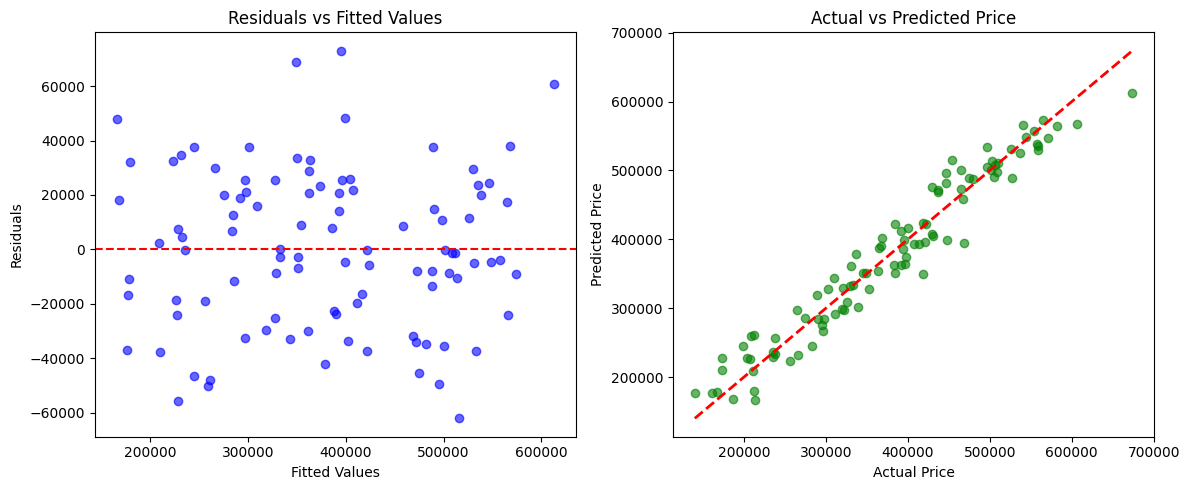

In [3]:
# 3. Diagnostik Model & Visualisasi Residuals
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Residual vs Fitted (Cek Heteroskedasticity)
axes[0].scatter(fitted_values, residuals, color='blue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

# Actual vs Predicted Plot
axes[1].scatter(df_house['Price'], predictions, color='green', alpha=0.6)
axes[1].plot([df_house['Price'].min(), df_house['Price'].max()],
             [df_house['Price'].min(), df_house['Price'].max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Actual vs Predicted Price')

plt.tight_layout()
plt.show()